In [1]:
%pip install numpy
%pip install pillow
%pip install matplotlib
%pip install tifffile 


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from pathlib import Path
import ast
import numpy as np
from PIL import Image
from itertools import permutations
import tifffile

# Configuración de rutas
base = Path().resolve().parent
carpeta_resultados = base / "Resultados"

ruta_cifrado = carpeta_resultados / "Img Cifrada.tiff"
ruta_meta = carpeta_resultados / "cifrado_meta.txt"

ruta_salida = carpeta_resultados / "Img Decifrada.png"


### Leer la llave y datos

In [3]:
def leer_metadatos(ruta_meta):
    datos = {}
    with open(str(ruta_meta), "r") as f:
        for linea in f:
            linea = linea.strip() 
            if not linea or "=" not in linea:
                continue # Salta las líneas vacías
            clave, valor = linea.split("=", 1)
            datos[clave.strip()] = valor.strip() # Guardar clave y valor en el diccionario
    return datos

# Datos en el txt que vienen junto a la imagen
meta = leer_metadatos(ruta_meta) 
key = ast.literal_eval(meta["Llave"]) 
x0 = float(meta["x0"]) 
iteraciones_usadas = int(meta["iteraciones_usadas"]) 


### Leer imagen TIFF

In [4]:
filas_R_cif = tifffile.imread(str(ruta_cifrado), key=1)
filas_G_cif = tifffile.imread(str(ruta_cifrado), key=2)
filas_B_cif = tifffile.imread(str(ruta_cifrado), key=3)

r_imag = tifffile.imread(str(ruta_cifrado), key=4).astype(np.float64)
g_imag = tifffile.imread(str(ruta_cifrado), key=5).astype(np.float64)
b_imag = tifffile.imread(str(ruta_cifrado), key=6).astype(np.float64)

r_signos = tifffile.imread(str(ruta_cifrado), key=7).astype(np.uint8)
g_signos = tifffile.imread(str(ruta_cifrado), key=8).astype(np.uint8)
b_signos = tifffile.imread(str(ruta_cifrado), key=9).astype(np.uint8)

h, w = r_imag.shape

def bits_pixel(total_bits_fila, w, rango=(1, 32)):
    posibles_bits = []
    for k in range(total_bits_fila - 7, total_bits_fila + 1):
        if k > 0 and k % w == 0:
            nb = k // w
            if rango[0] <= nb <= rango[1]:
                posibles_bits.append(nb) 
    return posibles_bits 

posibles_bits = bits_pixel(filas_R_cif.shape[1], w)

if posibles_bits:
    num_bits = posibles_bits[0]
else:
    num_bits = 8  

print(f"num_bits={num_bits}")


num_bits=13


## Permutación inversa

### Regeneración de reglas

In [5]:
def generar_con_logistico(x0, n, iteraciones_ignorar: int = 0, r: float = 3.99999):
    x = x0 
    for _ in range(iteraciones_ignorar):
        x = r * x * (1 - x)
    valores = []
    for _ in range(n):
        x = r * x * (1 - x)
        valores.append(x)
    return valores

def generar_indices_reglas(x0, n_filas, iteraciones_ignorar, r=3.99999):
    valores = generar_con_logistico(x0, n_filas, iteraciones_ignorar, r)
    reglas_idx = []
    
    for v in valores:
        # floor(v_i×10^14 )  mod 16
        v_abs = abs(v)
        frac = v_abs - int(v_abs)
        grande = int(frac * 10**14)
        # Ajusta el número al rango de 0 a 15 (índices de reglas)
        reglas_idx.append(grande % 16)
        
    return reglas_idx

reglas = generar_indices_reglas(x0, h, iteraciones_ignorar=iteraciones_usadas)


### Autómatas celulares

In [6]:
def regla_A(p, q, r):   return p          # 240: shift-right
def regla_C(p, q, r):   return r          # 170: shift-left
def regla_B(p, q, r):   return q          # 204: identity
def regla_Ab(p, q, r):  return 1 - p      # 15:  shift-right + complemento
def regla_Cb(p, q, r):  return 1 - r      # 85:  shift-left + complemento
def regla_Bb(p, q, r):  return 1 - q      # 51:  complemento

REGLAS = {
    'A': regla_A, 'C': regla_C, 'B': regla_B,
    'Ab': regla_Ab, 'Cb': regla_Cb, 'Bb': regla_Bb
}

TABLA2 = {
    0:  (['A','A','A','Ab','Ab','A','Ab','Ab'],   ['C','C','Cb','Cb','C','Cb','Cb','C']),
    1:  (['A','Ab','Ab','A','Ab','Ab','A','A'],   ['Cb','Cb','C','Cb','Cb','C','C','C']),
    2:  (['Ab','A','Ab','Ab','A','A','A','Ab'],   ['C','Cb','Cb','C','C','C','Cb','Cb']),
    3:  (['Ab','Ab','A','A','A','Ab','Ab','A'],   ['Cb','C','C','C','Cb','Cb','C','Cb']),
    4:  (['C','C','Cb','C','C','Cb','Cb','Cb'],   ['Ab','A','A','Ab','A','A','Ab','Ab']),
    5:  (['Cb','Cb','C','C','Cb','C','C','Cb'],   ['Ab','Ab','Ab','A','A','Ab','A','A']),
    6:  (['C','Cb','Cb','Cb','C','C','Cb','C'],   ['A','A','Ab','Ab','Ab','A','A','Ab']),
    7:  (['Cb','C','C','Cb','Cb','Cb','C','C'],   ['A','Ab','A','A','Ab','Ab','Ab','A']),
    8:  (['B','B','Bb','B','C','Ab','C','Ab'],    ['B','B','Bb','B','Cb','A','Cb','A']),
    9:  (['Bb','Cb','A','B','Cb','A','B','Bb'],   ['Bb','C','Ab','B','C','Ab','B','Bb']),
    10: (['C','Ab','Bb','Bb','B','C','Ab','B'],   ['Cb','A','Bb','Bb','B','Cb','A','B']),
    11: (['Bb','B','C','Ab','Bb','Bb','C','A'],   ['Bb','B','Cb','A','Bb','Bb','C','A']),
    12: (['Bb','Cb','A','C','A','Bb','Bb','B'],   ['Bb','C','Ab','C','A','Bb','Bb','B']),
    13: (['Bb','B','Bb','Cb','A','C','A','Bb'],   ['Bb','B','Bb','C','Ab','C','A','Bb']),
    14: (['C','A','B','Cb','Ab','B','Bb','Bb'],   ['C','A','B','Cb','Ab','B','Bb','Bb']),
    15: (['B','Bb','Cb','A','Bb','Cb','A','B'],   ['B','Bb','C','Ab','Bb','C','Ab','B']),
}

def evolucionar_bloque(bloque, reglas_8):
    longitud = len(bloque)
    nuevo = np.zeros(longitud, dtype=np.uint8)  # Arreglo para nuevo bloque de 8 bits
    
    for i in range(longitud):
        # Leer los vecinos de la fila original aplicando frontera segun la longitud de la fila
        izq = bloque[(i - 1) % longitud]
        cen = bloque[i]
        der = bloque[(i + 1) % longitud]
        
        # Aplica la regla específica asignada a la posición
        nuevo[i] = REGLAS[reglas_8[i]](izq, cen, der)
        
    return nuevo

def evolucionar_fila(fila_bits, reglas_8):
    r = 8 
    n = len(fila_bits)
    assert n % r == 0, f"La fila debe ser múltiplo de {r} (revisa el padding)"
    
    nueva_fila = np.zeros(n, dtype=np.uint8) # Arreglo para nueva fila
    for inicio in range(0, n, r):
        bloque = fila_bits[inicio:inicio + r]
        nueva_fila[inicio:inicio + r] = evolucionar_bloque(bloque, reglas_8)
        
    return nueva_fila

def descifrar_canal_ca(filas_cif, reglas_idx):
    filas_resultado = []
    # Recorrer cada fila cifrada junto con su respectivo índice de regla
    for fila, idx in zip(filas_cif, reglas_idx):
        reglas_8 = TABLA2[idx][1]  # [1] indica que se usa la regla inversa para descifrar
        filas_resultado.append(evolucionar_fila(fila, reglas_8))
    return filas_resultado

# Descifrar los tres canales usando las reglas regeneradas
filas_R = descifrar_canal_ca(filas_R_cif, reglas)
filas_G = descifrar_canal_ca(filas_G_cif, reglas)
filas_B = descifrar_canal_ca(filas_B_cif, reglas)


### Conversión binaria

In [7]:
def filas_a_matriz_pixeles(filas, n_bits, w):
    h = len(filas)
    matriz = np.zeros((h, w), dtype=np.int64)  # Matriz vacía para reconstruir la imagen
    
    for i, fila in enumerate(filas):
        # Descarta el relleno de la fila
        util = fila[:w * n_bits]
        
        # Reconstruye cada píxel agrupando los bits
        for j in range(w):
            bloque = util[j*n_bits:(j+1)*n_bits]
            # Convierte el bloque de bits de vuelta a un número entero decimal y lo guarda
            matriz[i, j] = int(''.join(str(b) for b in bloque), 2)
            
    return matriz

# Reconstruir matrices numéricas de la parte real para cada canal
R_int = filas_a_matriz_pixeles(filas_R, num_bits, w)
G_int = filas_a_matriz_pixeles(filas_G, num_bits, w)
B_int = filas_a_matriz_pixeles(filas_B, num_bits, w)


## Difusión inversa

### Reconstrucción de capas

In [8]:
def reconstruir_complejo(mag_real, mag_imag, signos):
    # Signos: 0 (+,+), 1 (-,+), 2 (+,-), 3 (-,-)  -- igual convención que en el cifrado
    signo_real = np.where(np.isin(signos, [1, 3]), -1, 1)
    signo_imag = np.where(np.isin(signos, [2, 3]), -1, 1)
    return (mag_real * signo_real) + 1j * (mag_imag * signo_imag)

def canal_2d_a_bloques(canal_2d):
    # Aplanar la matriz 2D y reorganizarla de vuelta en bloques (4, N)
    return canal_2d.flatten().reshape(4, -1)

# Reconstruir las matrices complejas para cada canal
c_r_2d = reconstruir_complejo(R_int, r_imag, r_signos)
c_g_2d = reconstruir_complejo(G_int, g_imag, g_signos)
c_b_2d = reconstruir_complejo(B_int, b_imag, b_signos)

# Convertir las matrices complejas de cada canal en bloques
bloques_r_cif = canal_2d_a_bloques(c_r_2d)
bloques_g_cif = canal_2d_a_bloques(c_g_2d)
bloques_b_cif = canal_2d_a_bloques(c_b_2d)


### Matrices y descifrado

In [9]:
def generar_matrices_4x4():

    # Definir las matrices de Pauli
    sigma_x = np.array([[0, 1],
                        [1, 0]], dtype=complex)

    sigma_y = np.array([[0, -1j],
                        [1j,  0]], dtype=complex)

    sigma_z = np.array([[1,  0],
                        [0, -1]], dtype=complex)

    I = np.eye(2, dtype=complex)

    ops = [I, sigma_x, sigma_y, sigma_z]

    matrices_4x4 = [] # Generar las permutaciones posibles para formar bloques de 4x4
    for M1, M2, M3, M4 in permutations(ops, 4):
        M = np.block([[M1, M2],
                      [M3, M4]])
        matrices_4x4.append(M)

    return matrices_4x4

def matrices_encriptacion(llave, matrices_rotacion): # Seleccionar la matriz correspondiente a cada elemento de la llave
    matrices_encript = []
    for item in llave:
        matrices_encript.append(matrices_rotacion[(item - 1) % 24])
    return matrices_encript

def descifrar_canal_pauli(bloque_cif, matrices_finales):
    resultado = bloque_cif.astype(complex)
    # Multiplicar por las matrices inversas en orden contrario para deshacer el cifrado
    for Mi in reversed(matrices_finales):
        resultado = np.linalg.inv(Mi) @ resultado
    return resultado

# Filtrar las matrices con la llave
matrices_rotadas = generar_matrices_4x4()
encriptacion = matrices_encriptacion(key, matrices_rotacion=matrices_rotadas)

p_r = descifrar_canal_pauli(bloques_r_cif, encriptacion)
p_g = descifrar_canal_pauli(bloques_g_cif, encriptacion)
p_b = descifrar_canal_pauli(bloques_b_cif, encriptacion)


### Reconstrucción final de la imagen

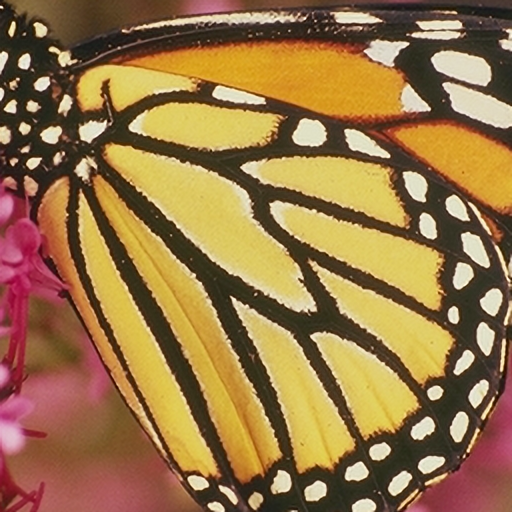

In [10]:
def bloques_a_canal(bloque_plano, h, w):
    real = np.round(bloque_plano.real).astype(np.int64)
    real = np.clip(real, 0, 255)
    return real.flatten().reshape(h, w).astype(np.uint8)

R_dec = bloques_a_canal(p_r, h, w)
G_dec = bloques_a_canal(p_g, h, w)
B_dec = bloques_a_canal(p_b, h, w)

imagen_rgb = np.stack([R_dec, G_dec, B_dec], axis=-1)
imagen_decifrada = Image.fromarray(imagen_rgb, mode='RGB')
display(imagen_decifrada)
imagen_decifrada.save(str(ruta_salida))
